In [98]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [99]:
def mostrar_imagen(imagen, titulo=''):
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

## Algorithm for image quality measure 
Paper: Image Sharpness Measure for Blurred Images in Frequency Domain 

In [100]:
# Function to calculate the Frequency Domain Image Blur Measure (FM)
# Input: Image I of size M×N.  
# Output: Image Quality measure (FM) where FM stands for Frequency Domain Image Blur Measure 
# Step 1: Compute F which is the Fourier Transform representation of image I   
# Step 2:  Find Fc which is obtained by shifting the origin of F to centre. 
#  Step 3: Calculate AF = abs (Fc) where AF is the absolute value of the centered Fourier transform of image I. 
#  Step 4:  Calculate M = max (AF) where M is the maximum value of the frequency component in F. 
# Step 5: Calculate TH = the total number of pixels in F whose pixel value > thres, where thres = M/1000. 
# Step 6: Calculate Image Quality measure (FM) from equation (1). 
# FM = TH / (M * M)  (1)

def calcular_fm(frame):
    img = np.fft.fft2(frame)
    img_fft = np.fft.fftshift(img)
    AF = np.abs(img_fft)
    M = np.max(AF)
    thres = M / 1000
    TH = np.sum(AF > thres)
    FM = TH / (M * M)
    return FM

## Funcion para extraer un ROI centrado

In [101]:
def obtener_roi_central(frame, porcentaje_area):
    alto, ancho = frame.shape[:2]
    
    # El factor de escala para los lados es la raíz cuadrada del área
    factor = porcentaje_area**0.5
    
    # Calculamos nuevas dimensiones
    roi_w = int(ancho * factor)
    roi_h = int(alto * factor)
    
    # Calculamos coordenadas de inicio para centrar
    x_inicio = (ancho - roi_w) // 2
    y_inicio = (alto - roi_h) // 2
    
    return frame[y_inicio:y_inicio+roi_h, x_inicio:x_inicio+roi_w]

## Funcion para identificar el frame y valor FM maximo

In [102]:
# Identificar el frame con el valor FM máximo para cada caso
def identificar_frame_max_fm(frame_fm_values):
    max_fm_frame = max(frame_fm_values, key=frame_fm_values.get)
    max_fm_value = frame_fm_values[max_fm_frame]
    return max_fm_frame, max_fm_value

## Bucle para obtener el indicador de calidad de imagen de maximo enfoque para frame completo, ROI 5% y 10% (sin unsharp masking)

In [103]:
# Abre el video
video_path = 'focus_video.mov'
captura_video = cv2.VideoCapture(video_path)

total_frames = int(captura_video.get(cv2.CAP_PROP_FRAME_COUNT))

frame_fm_values = {}
frame_fm_values_roi_5 = {}
frame_fm_values_roi_10 = {}

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    for i in range(total_frames):
        ret, frame = captura_video.read()
        if ret:
            # Frames Totales y ROI Central 5 y 10%
            frame_ROI_5 = obtener_roi_central(frame, 0.05)
            frame_ROI_10 = obtener_roi_central(frame, 0.1)
            # Mostrar los frames
            # mostrar_imagen(frame_ROI_5, titulo=f'Frame {i+1} - ROI Central (5%)')
            # mostrar_imagen(frame_ROI_10, titulo=f'Frame {i+1} - ROI Central (10%)')
            # mostrar_imagen(frame, titulo=f'Frame {i+1} - Frame Completo')

            # Calcular el valor FM para el frame total y ROI central 5 y 10%
            fm_value = calcular_fm(frame)
            frame_fm_values[i+1] = fm_value

            fm_value_roi_5 = calcular_fm(frame_ROI_5)
            frame_fm_values_roi_5[i+1] = fm_value_roi_5

            fm_value_roi_10 = calcular_fm(frame_ROI_10)
            frame_fm_values_roi_10[i+1] = fm_value_roi_10
        else:
            break

# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()

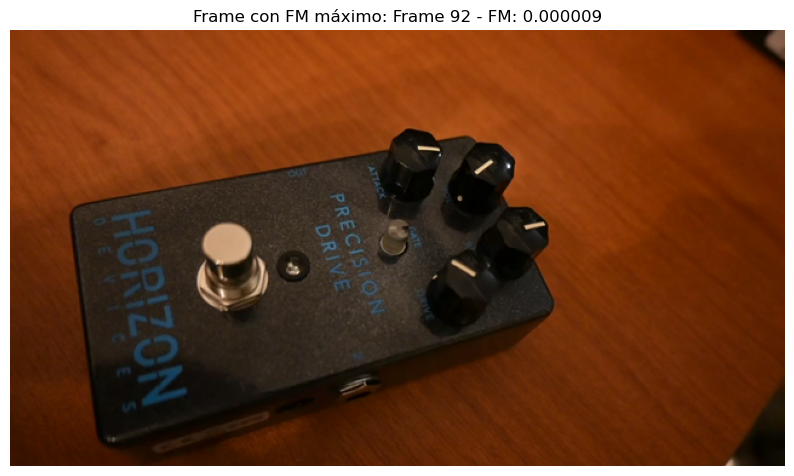

--- Image Quality Measure - Frame Completo ---
El frame con el valor FM máximo es el Frame 92 con un valor FM de 0.000009
----------------------


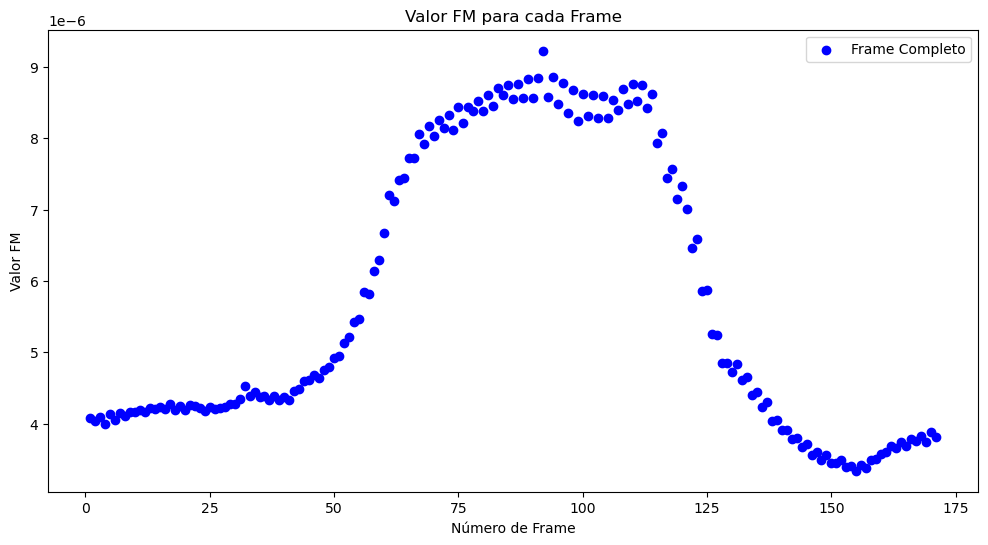

In [104]:
# Abre el video nuevamente para mostrar un frame específico
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

max_fm_frame, max_fm_value = identificar_frame_max_fm(frame_fm_values)
captura_video.set(cv2.CAP_PROP_POS_FRAMES, max_fm_frame - 1)  # Ir al frame específico (restamos 1 porque los frames comienzan en 0)

ret, frame = captura_video.read()

mostrar_imagen(frame, titulo=f'Frame con FM máximo: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
captura_video.release()
cv2.destroyAllWindows()

print('--- Image Quality Measure - Frame Completo ---')
print(f"El frame con el valor FM máximo es el Frame {max_fm_frame} con un valor FM de {max_fm_value:.6f}")
print('----------------------')
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values.keys(), frame_fm_values.values(), label='Frame Completo', color='blue')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.show()

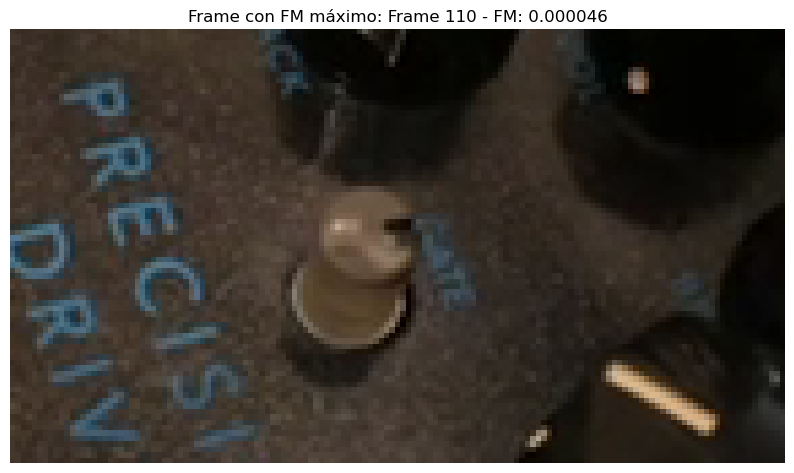

--- Image Quality Measure - Frame ROI 5% ---
El frame con el valor FM máximo es el Frame 110 con un valor FM de 0.000046
----------------------


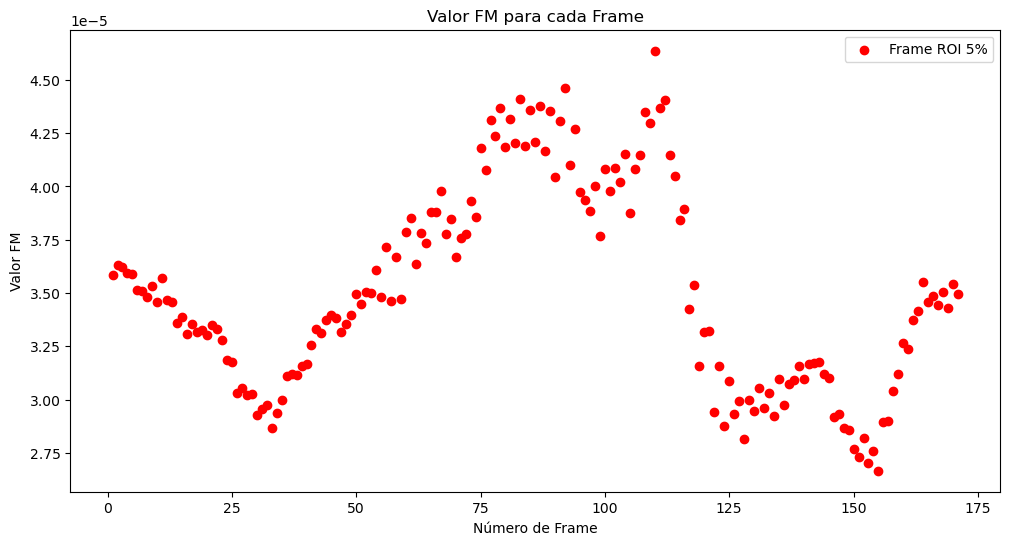

In [105]:
# Abre el video nuevamente para mostrar un frame específico
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

max_fm_frame, max_fm_value = identificar_frame_max_fm(frame_fm_values_roi_5)
captura_video.set(cv2.CAP_PROP_POS_FRAMES, max_fm_frame - 1)  # Ir al frame específico (restamos 1 porque los frames comienzan en 0)

ret, frame = captura_video.read()
frame = obtener_roi_central(frame, 0.05)  # Obtener ROI central 5% del frame
mostrar_imagen(frame, titulo=f'Frame con FM máximo: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
captura_video.release()
cv2.destroyAllWindows()

print('--- Image Quality Measure - Frame ROI 5% ---')
print(f"El frame con el valor FM máximo es el Frame {max_fm_frame} con un valor FM de {max_fm_value:.6f}")
print('----------------------')
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values_roi_5.keys(), frame_fm_values_roi_5.values(), label='Frame ROI 5%', color='red')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.show()

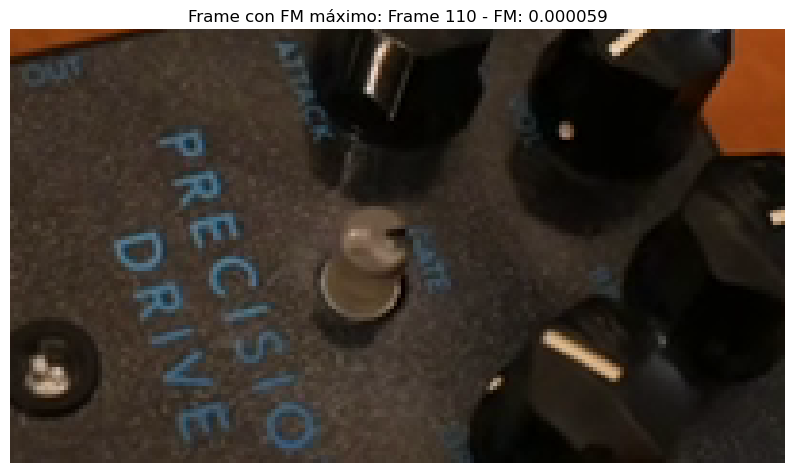

--- Image Quality Measure - Frame ROI 10% ---
El frame con el valor FM máximo es el Frame 110 con un valor FM de 0.000059
----------------------


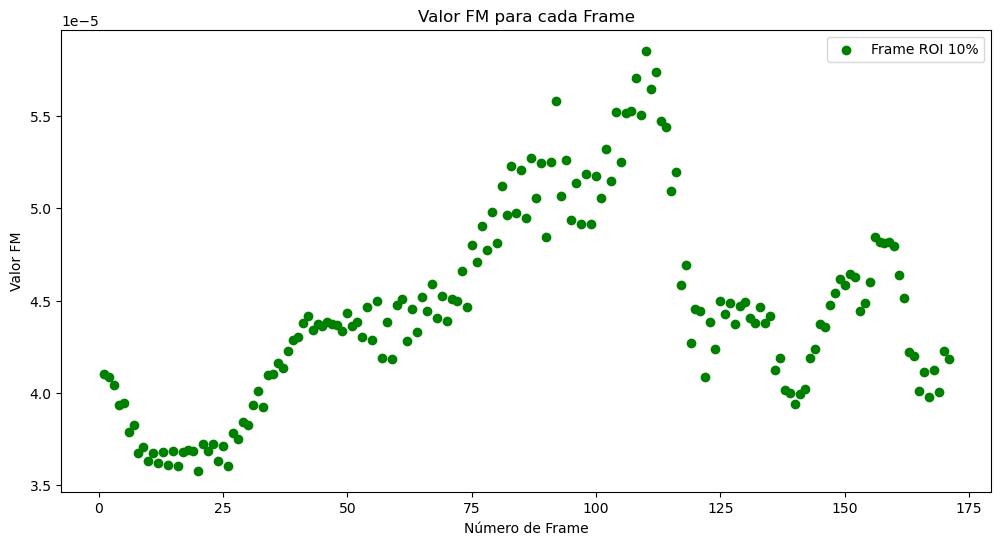

In [106]:
# Abre el video nuevamente para mostrar un frame específico
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

max_fm_frame, max_fm_value = identificar_frame_max_fm(frame_fm_values_roi_10)
captura_video.set(cv2.CAP_PROP_POS_FRAMES, max_fm_frame - 1)  # Ir al frame específico (restamos 1 porque los frames comienzan en 0)

ret, frame = captura_video.read()
frame = obtener_roi_central(frame, 0.1)  # Obtener ROI central 10% del frame
mostrar_imagen(frame, titulo=f'Frame con FM máximo: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
captura_video.release()
cv2.destroyAllWindows()

print('--- Image Quality Measure - Frame ROI 10% ---')
print(f"El frame con el valor FM máximo es el Frame {max_fm_frame} con un valor FM de {max_fm_value:.6f}")
print('----------------------')
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values_roi_10.keys(), frame_fm_values_roi_10.values(), label='Frame ROI 10%', color='green')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.show()

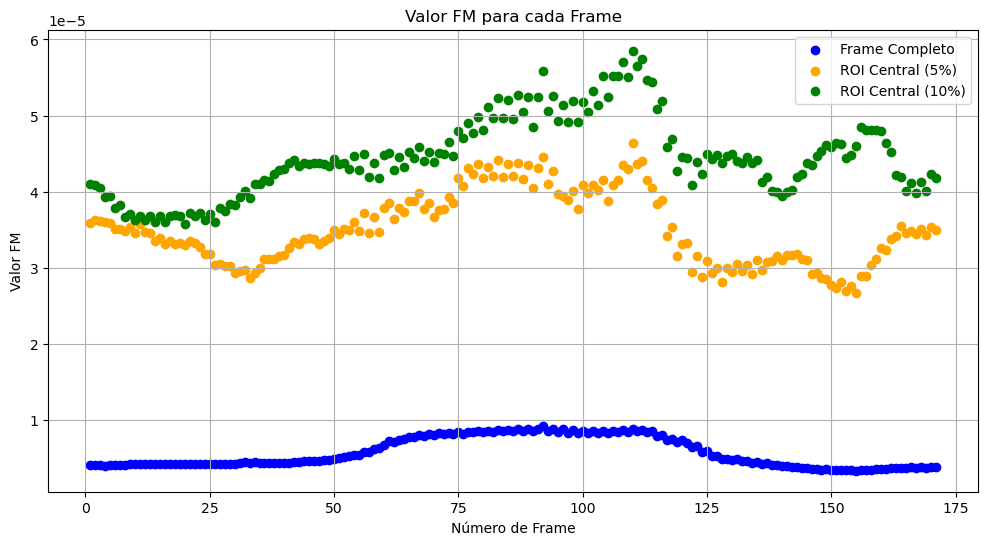

In [107]:
# Imprime los valores FM para cada frame total y ROI central 5 y 10% en un scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values.keys(), frame_fm_values.values(), label='Frame Completo', color='blue')
plt.scatter(frame_fm_values_roi_5.keys(), frame_fm_values_roi_5.values(), label='ROI Central (5%)', color='orange')
plt.scatter(frame_fm_values_roi_10.keys(), frame_fm_values_roi_10.values(), label='ROI Central (10%)', color='green')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.grid()

## Agregando funcion de Unsharp Masking

In [132]:
def aplicar_unsharp_masking(img, sigma=0.5, strength=1): ## usaremos sigma=0.5 y strength=1
    # Desenfoque de la imagen con un filtro suavizador 
    gauss = cv2.GaussianBlur(img, (0, 0), sigma)
    
    # Calcular la diferencia y sumarla (addWeighted hace la mezcla)
    sharpened = cv2.addWeighted(img, 1.0 + strength, gauss, -strength, 0)
    
    return sharpened

## Bucle para obtener el indicador de calidad de imagen de maximo enfoque para frame completo, ROI 5% y 10% (con unsharp masking)

In [133]:
# Abre el video
video_path = 'focus_video.mov'
captura_video = cv2.VideoCapture(video_path)

total_frames = int(captura_video.get(cv2.CAP_PROP_FRAME_COUNT))

frame_fm_values = {}
frame_fm_values_roi_5 = {}
frame_fm_values_roi_10 = {}

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    for i in range(total_frames):
        ret, frame = captura_video.read()
        if ret:
            # Frames Totales y ROI Central 5 y 10%
            frame_ROI_5 = obtener_roi_central(frame, 0.05)
            frame_ROI_10 = obtener_roi_central(frame, 0.1)
            # Mostrar los frames
            # mostrar_imagen(frame_ROI_5, titulo=f'Frame {i+1} - ROI Central (5%)')
            # mostrar_imagen(frame_ROI_10, titulo=f'Frame {i+1} - ROI Central (10%)')
            # mostrar_imagen(frame, titulo=f'Frame {i+1} - Frame Completo')

            # Aplicar unsharp masking a cada frame         
            frame = aplicar_unsharp_masking(frame)  # Aplicar unsharp masking a cada frame
            frame_ROI_5 = aplicar_unsharp_masking(frame_ROI_5)  # Aplicar unsharp masking a ROI 5%
            frame_ROI_10 = aplicar_unsharp_masking(frame_ROI_10)  # Aplicar unsharp masking a ROI 10%

            # Calcular el valor FM para el frame total y ROI central 5 y 10%
            fm_value = calcular_fm(frame)
            frame_fm_values[i+1] = fm_value

            fm_value_roi_5 = calcular_fm(frame_ROI_5)
            frame_fm_values_roi_5[i+1] = fm_value_roi_5

            fm_value_roi_10 = calcular_fm(frame_ROI_10)
            frame_fm_values_roi_10[i+1] = fm_value_roi_10
        else:
            break

# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()

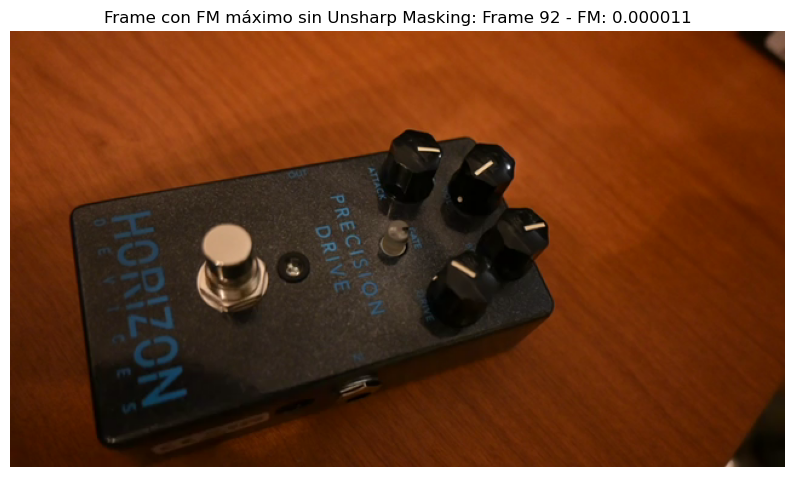

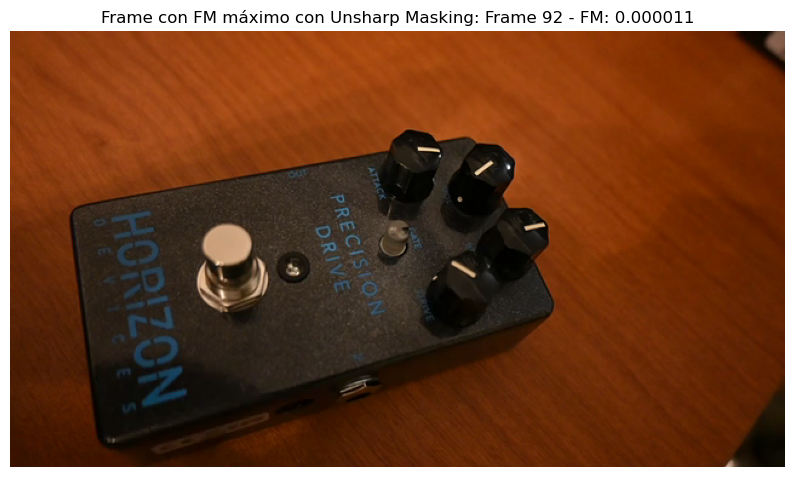

--- Image Quality Measure - Frame Completo ---
El frame con el valor FM máximo es el Frame 92 con un valor FM de 0.000011
----------------------


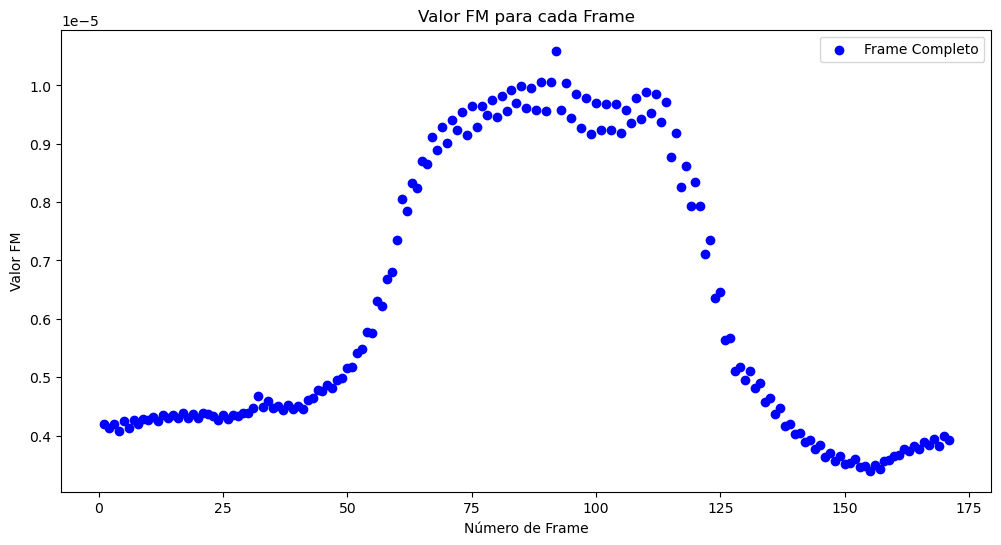

In [134]:
# Abre el video nuevamente para mostrar un frame específico
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

max_fm_frame, max_fm_value = identificar_frame_max_fm(frame_fm_values)
captura_video.set(cv2.CAP_PROP_POS_FRAMES, max_fm_frame - 1)  # Ir al frame específico (restamos 1 porque los frames comienzan en 0)

ret, frame = captura_video.read()
mostrar_imagen(frame, titulo=f'Frame con FM máximo sin Unsharp Masking: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
frame = aplicar_unsharp_masking(frame)
mostrar_imagen(frame, titulo=f'Frame con FM máximo con Unsharp Masking: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
captura_video.release()
cv2.destroyAllWindows()

print('--- Image Quality Measure - Frame Completo ---')
print(f"El frame con el valor FM máximo es el Frame {max_fm_frame} con un valor FM de {max_fm_value:.6f}")
print('----------------------')
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values.keys(), frame_fm_values.values(), label='Frame Completo', color='blue')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.show()

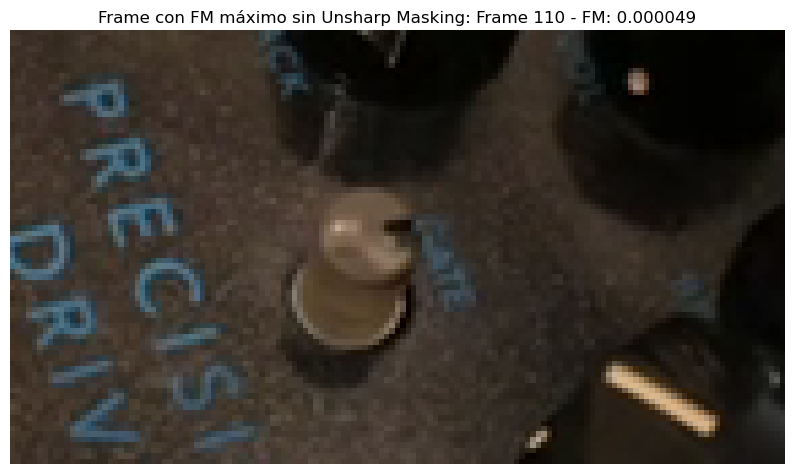

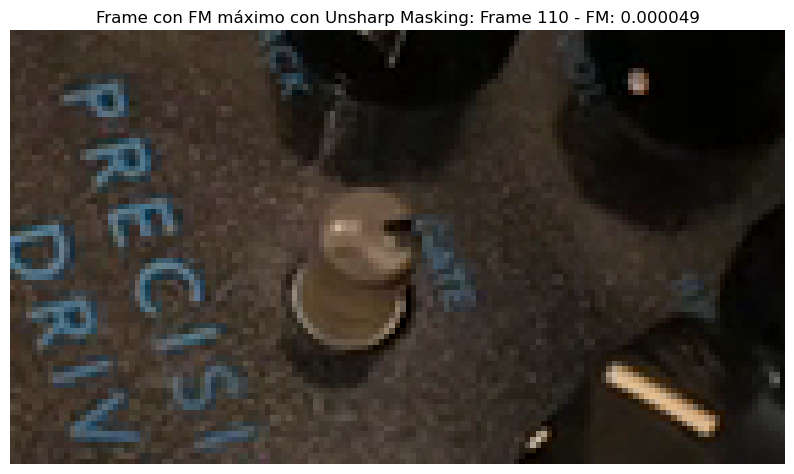

--- Image Quality Measure - Frame ROI 5% ---
El frame con el valor FM máximo es el Frame 110 con un valor FM de 0.000049
----------------------


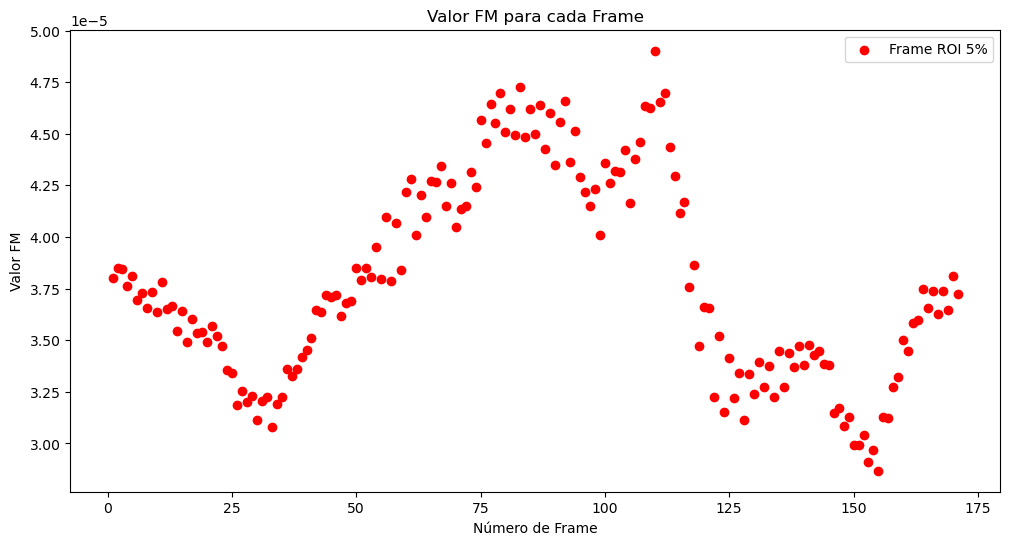

In [135]:
# Abre el video nuevamente para mostrar un frame específico
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

max_fm_frame, max_fm_value = identificar_frame_max_fm(frame_fm_values_roi_5)
captura_video.set(cv2.CAP_PROP_POS_FRAMES, max_fm_frame - 1)  # Ir al frame específico (restamos 1 porque los frames comienzan en 0)

ret, frame = captura_video.read()
frame = obtener_roi_central(frame, 0.05)  # Obtener ROI central 5% del frame
mostrar_imagen(frame, titulo=f'Frame con FM máximo sin Unsharp Masking: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
frame = aplicar_unsharp_masking(frame)
mostrar_imagen(frame, titulo=f'Frame con FM máximo con Unsharp Masking: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
captura_video.release()
cv2.destroyAllWindows()

print('--- Image Quality Measure - Frame ROI 5% ---')
print(f"El frame con el valor FM máximo es el Frame {max_fm_frame} con un valor FM de {max_fm_value:.6f}")
print('----------------------')
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values_roi_5.keys(), frame_fm_values_roi_5.values(), label='Frame ROI 5%', color='red')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.show()

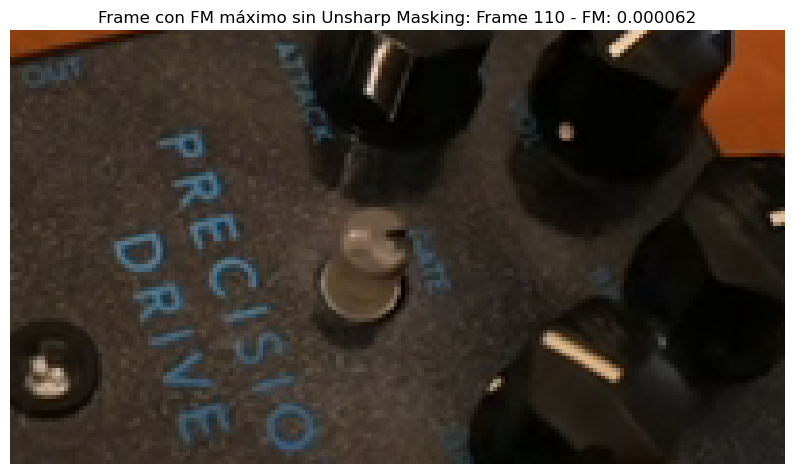

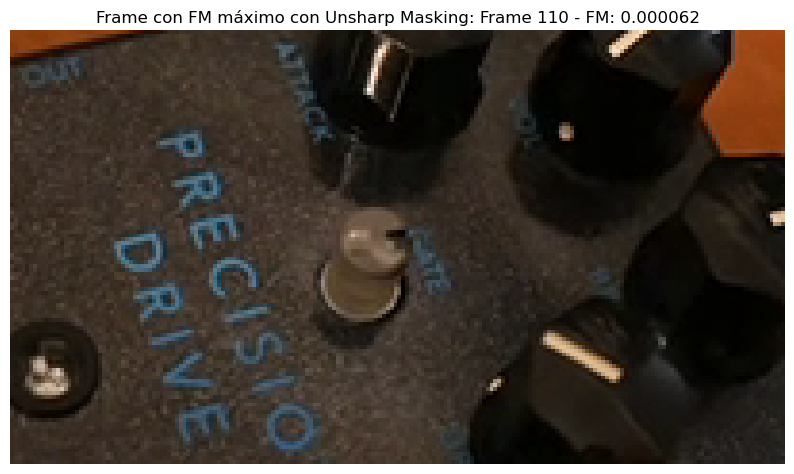

--- Image Quality Measure - Frame ROI 10% ---
El frame con el valor FM máximo es el Frame 110 con un valor FM de 0.000062
----------------------


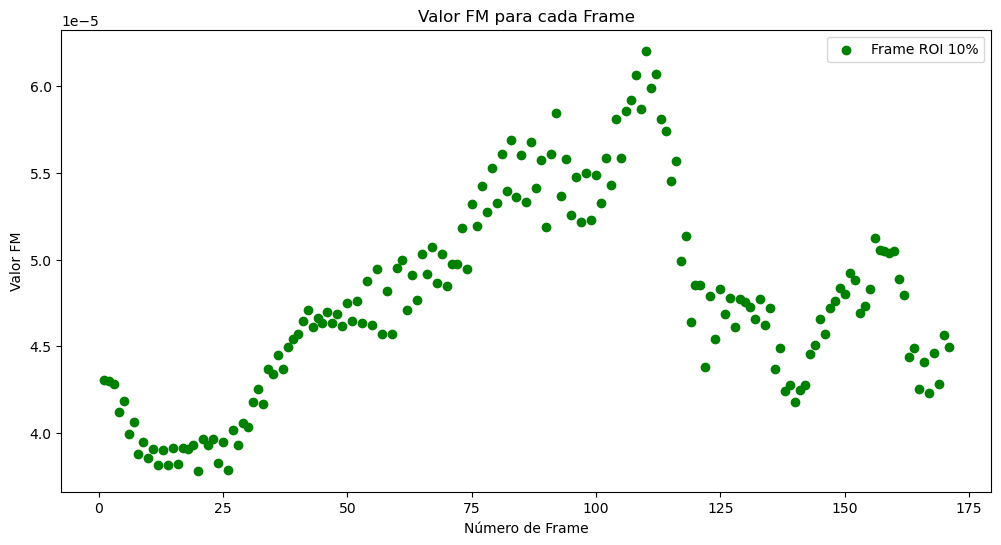

In [136]:
# Abre el video nuevamente para mostrar un frame específico
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

max_fm_frame, max_fm_value = identificar_frame_max_fm(frame_fm_values_roi_10)
captura_video.set(cv2.CAP_PROP_POS_FRAMES, max_fm_frame - 1)  # Ir al frame específico (restamos 1 porque los frames comienzan en 0)

ret, frame = captura_video.read()
frame = obtener_roi_central(frame, 0.1)  # Obtener ROI central 10% del frame
mostrar_imagen(frame, titulo=f'Frame con FM máximo sin Unsharp Masking: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
frame = aplicar_unsharp_masking(frame)
mostrar_imagen(frame, titulo=f'Frame con FM máximo con Unsharp Masking: Frame {max_fm_frame} - FM: {max_fm_value:.6f}')
captura_video.release()
cv2.destroyAllWindows()

print('--- Image Quality Measure - Frame ROI 10% ---')
print(f"El frame con el valor FM máximo es el Frame {max_fm_frame} con un valor FM de {max_fm_value:.6f}")
print('----------------------')
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values_roi_10.keys(), frame_fm_values_roi_10.values(), label='Frame ROI 10%', color='green')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.show()

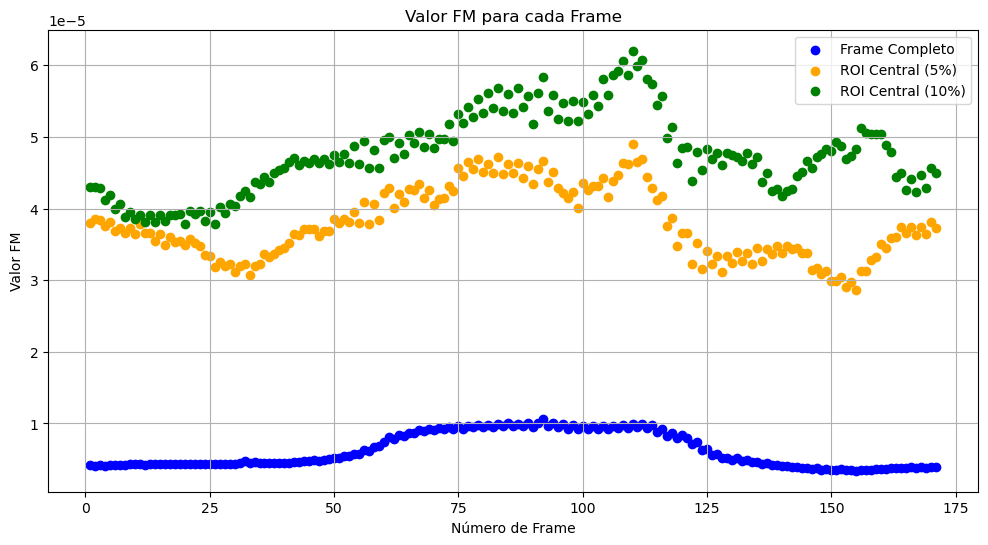

In [137]:
# Imprime los valores FM para cada frame total y ROI central 5 y 10% en un scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(frame_fm_values.keys(), frame_fm_values.values(), label='Frame Completo', color='blue')
plt.scatter(frame_fm_values_roi_5.keys(), frame_fm_values_roi_5.values(), label='ROI Central (5%)', color='orange')
plt.scatter(frame_fm_values_roi_10.keys(), frame_fm_values_roi_10.values(), label='ROI Central (10%)', color='green')
plt.title('Valor FM para cada Frame')
plt.xlabel('Número de Frame')
plt.ylabel('Valor FM')
plt.legend()
plt.grid()

## Conclusiones

* Cuando usamos el frame completo, el frame optimo donde se obtiene el maximo enfoque (con o sin unsharp masking) se mantiene en 92.
* Cuando usamos usamos un ROI de 5% y 10%, el frame optimo donde se obtiene el maximo enfoque (con o sin unsharp masking) se mantiene en 110.
* No obstante, cuando se aplica Highboost Filtering con un parametro de fuerza equivalante a 10 o más, el frame ROI 5% suele ser muy volatil (el 10% en menor medida) y fragil en identificar al punto de maximo enfoque